## Importing Libraries

In [25]:
# Text Preprocessing Libraries
import re
import nltk

from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

nltk.download('stopwords')
stop_words = set(stopwords.words('english'))
stem = PorterStemmer()

[nltk_data] Downloading package stopwords to C:\Users\Purvi
[nltk_data]     jain\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score,recall_score,confusion_matrix,classification_report

## Dataset

In [27]:
df = pd.read_csv("../00_Datasets/fake_and_real_news.csv")

In [28]:
df.head()

,Text,label
0,Top Trump Surrogate BRUTALLY Stabs Him In The...,Fake
1,U.S. conservative leader optimistic of common ...,Real
2,"Trump proposes U.S. tax overhaul, stirs concer...",Real
3,Court Forces Ohio To Allow Millions Of Illega...,Fake
4,Democrats say Trump agrees to work on immigrat...,Real


In [29]:
df.shape

(9900, 2)

In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9900 entries, 0 to 9899
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Text    9900 non-null   object
 1   label   9900 non-null   object
dtypes: object(2)
memory usage: 154.8+ KB


In [31]:
df.isnull().sum()

Text     0
label    0
dtype: int64

In [32]:
df.duplicated().sum()

np.int64(35)

In [33]:
df.drop_duplicates(inplace=True)

## Text Cleaning

In [35]:
def clean_text(text):
    text = re.sub('[^a-zA-Z0-9]', ' ', str(text))
    text = text.lower()
    text = text.split()

    text = [
        stem.stem(word)
        for word in text
        if word not in stop_words
    ]

    return ' '.join(text)

In [36]:
df['clean_text'] = df['Text'].apply(clean_text)

In [37]:
df.head()

,Text,label,clean_text
0,Top Trump Surrogate BRUTALLY Stabs Him In The...,Fake,top trump surrog brutal stab back pathet video...
1,U.S. conservative leader optimistic of common ...,Real,u conserv leader optimist common ground health...
2,"Trump proposes U.S. tax overhaul, stirs concer...",Real,trump propos u tax overhaul stir concern defic...
3,Court Forces Ohio To Allow Millions Of Illega...,Fake,court forc ohio allow million illeg purg voter...
4,Democrats say Trump agrees to work on immigrat...,Real,democrat say trump agre work immigr bill wall ...


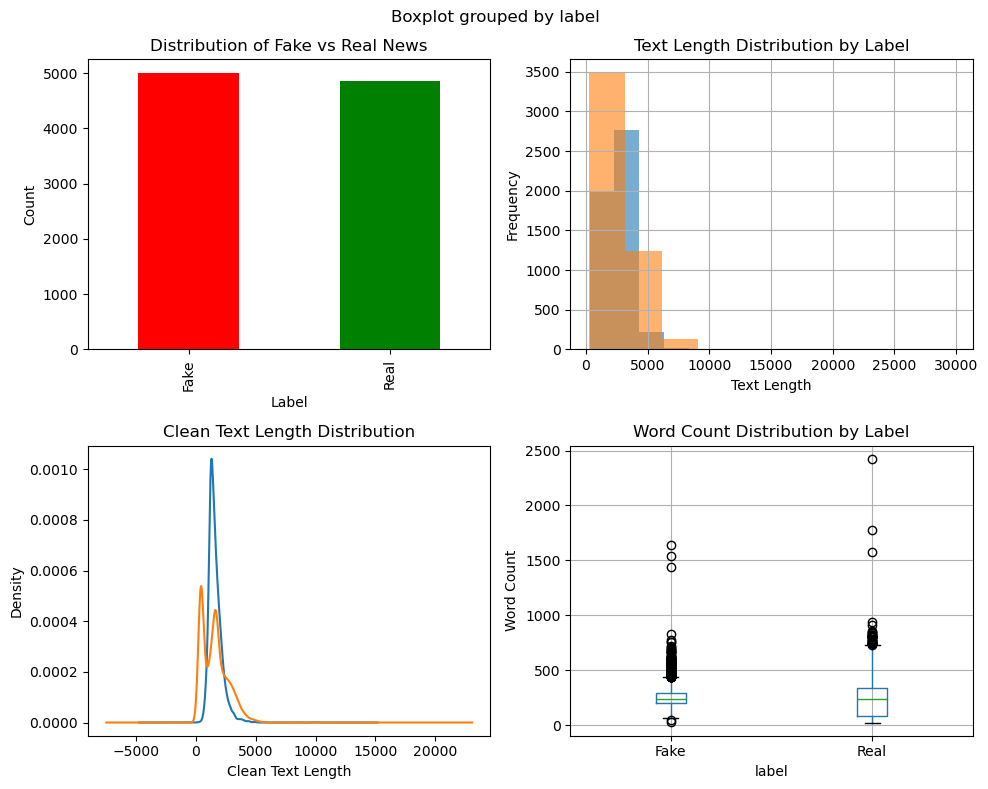

In [38]:
# Create a figure with multiple subplots
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

# 1. Distribution of labels
df['label'].value_counts().plot(kind='bar', ax=axes[0, 0], color=['red', 'green'])
axes[0, 0].set_title('Distribution of Fake vs Real News')
axes[0, 0].set_ylabel('Count')
axes[0, 0].set_xlabel('Label')

# 2. Text length distribution by label
df['text_length'] = df['Text'].apply(len)
df.groupby('label')['text_length'].hist(ax=axes[0, 1], alpha=0.6)
axes[0, 1].set_title('Text Length Distribution by Label')
axes[0, 1].set_xlabel('Text Length')
axes[0, 1].set_ylabel('Frequency')

# 3. Clean text length distribution
df['clean_text_length'] = df['clean_text'].apply(len)
df.groupby('label')['clean_text_length'].plot(kind='kde', ax=axes[1, 0])
axes[1, 0].set_title('Clean Text Length Distribution')
axes[1, 0].set_xlabel('Clean Text Length')

# 4. Word count distribution by label
df['word_count'] = df['clean_text'].apply(lambda x: len(x.split()))
df.boxplot(column='word_count', by='label', ax=axes[1, 1])
axes[1, 1].set_title('Word Count Distribution by Label')
axes[1, 1].set_ylabel('Word Count')

plt.tight_layout()
plt.show()

In [39]:
# Feature Extraction using TF-IDF Vectorizer

vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1,2))
X = vectorizer.fit_transform(df['clean_text'])
y = df['label']

In [40]:
# Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

## Model

In [41]:
model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [42]:
y_pred = model.predict(X_test)

In [43]:
print("Accuracy : ", accuracy_score(y_test, y_pred))
print("Classification Report \n", classification_report(y_test, y_pred))

Accuracy :  0.9929042067916878
Classification Report 
               precision    recall  f1-score   support

        Fake       0.99      0.99      0.99       977
        Real       0.99      0.99      0.99       996

    accuracy                           0.99      1973
   macro avg       0.99      0.99      0.99      1973
weighted avg       0.99      0.99      0.99      1973



In [44]:
y.value_counts()

label
Fake    5000
Real    4865
Name: count, dtype: int64

## Testing

In [45]:
test_news = [
    "Government announces free 10 lakh to every citizen starting next month"
]

test_clean = [clean_text(test_news[0])]
vector = vectorizer.transform(test_clean)
model.predict(vector)

array(['Real'], dtype=object)

In [46]:
test_news = [
"Scientists discover a miracle herb that cures cancer in 7 days"
]

test_clean = [clean_text(test_news[0])]
vector = vectorizer.transform(test_clean)
model.predict(vector)

array(['Fake'], dtype=object)

In [47]:
test_news = [
    "RBI increased the repo rate by 25 basis points to control inflation",
    "Supreme Court directed states to submit air pollution reports",
    "New study reveals that switching off mobile phones at night can increase human lifespan by 20 years.",
    "Scientists claim drinking hot water with lemon can completely cure COVID-19 and all future viruses within 48 hours."
]

test_clean = [clean_text(news) for news in test_news]
vector = vectorizer.transform(test_clean)
model.predict(vector)

array(['Real', 'Real', 'Fake', 'Fake'], dtype=object)